In [ ]:
pip install torch torchvision --quiet


Note: you may need to restart the kernel to use updated packages.


Imports & Device

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.models as models
import os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Configuration du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


Definir les transformations dans les datasets

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


 Appliquer les transformations dans les datasets

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset = ImageFolder("Dataset/train", transform=train_transform)
test_dataset = ImageFolder("Dataset/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_names = train_dataset.classes


Visualisation des images augmentées

C:\Users\Niraj\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


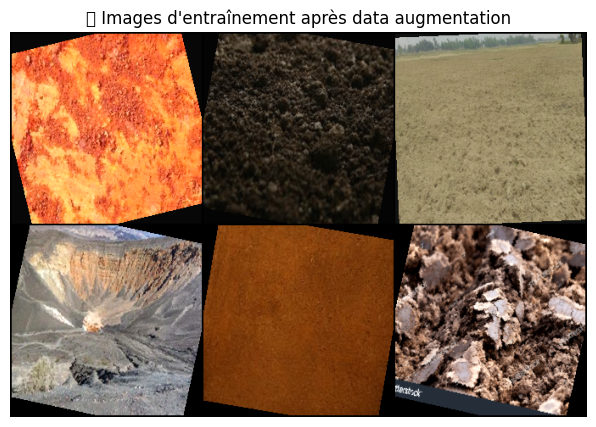

In [ ]:
import matplotlib.pyplot as plt
import torchvision

# Fonction d'affichage
def show_augmented_images(data_loader):
    images, labels = next(iter(data_loader))
    images = images[:6]  # on affiche 6 images
    labels = labels[:6]

    # Annulation de la normalisation pour affichage
    unnorm = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    images = torch.stack([unnorm(img) for img in images])

    grid = torchvision.utils.make_grid(images, nrow=3)
    plt.figure(figsize=(10, 5))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title("🌱 Images d'entraînement après data augmentation")
    plt.show()

# Affichage
show_augmented_images(train_loader)


Initialisation du modèle


In [ ]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)


c:\Users\Niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Définition loss, optimizer, scheduler, early stopping

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

best_loss = float('inf')
patience = 3
patience_counter = 0

# Tracking des métriques
history = {
    'train_loss': [],
    'val_loss': [],
    'accuracy': [],
    'lr': []
}


Entraînement avec suivi

Chargement du meilleur modèle

In [27]:
# Charger le modèle entraîné

model.load_state_dict(torch.load("best_soil_model.pth",map_location=torch.device('cpu')))  # Si GPU → remplacer 'cpu' par 'cuda'
model.eval()
print("✅ Modèle chargé et prêt pour l'inférence.")



✅ Modèle chargé et prêt pour l'inférence.


Fonction de prédiction sur une image

In [30]:
from PIL import Image

def predict_image(image_path, model, class_names):
    image = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = torch.max(outputs, 1)
        probas = torch.nn.functional.softmax(outputs, dim=1)[0]
        confidence = probas[predicted.item()].item()

    predicted_class = class_names[predicted.item()]
    return predicted_class, confidence


Chargement du fichier CSV pour la couleur du sol

Tester une image locale

In [47]:
# 🔎 Remplace par le chemin vers une de tes images
image_path = "Dataset/test/Red soil/red3.jpg"
predicted_label, confidence = predict_image(image_path, model, class_names)
print(f"🧠 Type de sol prédit : {predicted_label} (Confiance : {confidence:.2%})")


TypeError: 'Pipeline' object is not callable

 la couleur dominante

In [34]:
import random

# Mapping propre
soil_color_mapping = {
    'clay soil': ['gray'],
    'alluvial soil': ['brown', 'yellowish brown', 'dark brown',  'lightish brown', 'other'],
    'black soil': ['black'],
    'red soil': ['red', 'reddish brown']
}

def get_plausible_color(soil_type):
    soil_type = soil_type.lower().strip()
    if soil_type not in soil_color_mapping:
        return "❌ Type inconnu"
    return random.choice(soil_color_mapping[soil_type])


 Exemple

In [35]:
sol_cnn = predicted_label  # Sortie de ton CNN
color_assignee = get_plausible_color(sol_cnn)
print(f"🧠 Type : {sol_cnn} → 🎨 Couleur plausible : {color_assignee}")


🧠 Type : Red soil → 🎨 Couleur plausible : reddish brown


Extraction de proprietes a partir de la couleur

In [36]:
import pandas as pd
import csv
from io import StringIO
import numpy as np

def get_avg_soil_properties_from_csv(color, filepath='soil crop recommendation.txt'):
    try:
        # 1. Lire le fichier comme texte brut
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # 2. Corriger le format - chaque ligne doit être une entrée distincte
        lines = content.split('\n')
        header = lines[0]
        data_lines = lines[1:]
        
        # 3. Recréer un CSV valide
        corrected_content = header + '\n' + '\n'.join(data_lines)
        
        # 4. Lire avec pandas en spécifiant le séparateur et la gestion des guillemets
        df = pd.read_csv(StringIO(corrected_content), sep=',', quoting=csv.QUOTE_MINIMAL)
        
        # 5. Vérifier que 'Soilcolor' est bien une colonne
        if 'Soilcolor' not in df.columns:
            return {
                'error': "La colonne 'Soilcolor' existe mais n'a pas été correctement interprétée",
                'raw_first_line': lines[0] if len(lines) > 0 else "Fichier vide",
                'columns_found': df.columns.tolist(),
                'suggestion': "Vérifiez le séparateur utilisé dans le fichier (virgule ',' ou tabulation '\t')"
            }
        
        # 6. Nettoyer et standardiser les couleurs
        df['Soilcolor'] = df['Soilcolor'].str.strip('"').str.strip().str.lower()
        
        color_mapping = {
            'redish brown': 'reddish brown',
            'darkbrown': 'dark brown',
            'redish gray': 'reddish gray',
            'grayish brown': 'gray brown',
            'yellowish brown': 'yellowish brown',
            'lihgtish brown': 'lightish brown',
            'redishbrown': 'reddish brown'
        }
        df['Soilcolor'] = df['Soilcolor'].replace(color_mapping)
        
        # 7. Vérifier si la couleur existe
        if color.lower() not in df['Soilcolor'].unique():
            return {
                'error': f"Couleur '{color}' non trouvée",
                'available_colors': df['Soilcolor'].unique().tolist()
            }
        
        # 8. Filtrer et calculer les propriétés
        color_data = df[df['Soilcolor'] == color.lower()]
        
        
        properties = {
            'pH': round(color_data['Ph'].mean(), 4),
            'N': round(color_data['N'].mean(), 4),
            'P': round(color_data['P'].mean(), 4),
            'K': round(color_data['K'].mean(), 4),
            'humidity': round(color_data['GWETTOP'].mean(), 4),
            'temperature': round(color_data[[c for c in color_data.columns if 'T2M_MAX' in c]].mean().mean(), 4),
            'precipitation': round(color_data[[c for c in color_data.columns if 'PRECTOTCORR' in c]].mean().mean(), 4)
        }
        
        return properties
    
    except Exception as e:
        return {
            'error': f"Erreur lors du traitement: {str(e)}",
            'raw_first_line': lines[0] if len(lines) > 0 else "Fichier vide",
            'suggestion': "Vérifiez l'encodage (UTF-8 ou latin1), le séparateur (virgule ',' ou tabulation '\t'), ou l'intégrité du fichier"
        }



Exemple d'utilisation

In [37]:
# Obtenir les propriétés
properties = get_avg_soil_properties_from_csv(color_assignee)
print(properties)



{'pH': 5.5291, 'N': 0.2014, 'P': 6.2982, 'K': 303.7487, 'humidity': 0.696, 'temperature': 26.0896, 'precipitation': 6.3893}


Entraînement du modèle KNN

Prédiction des cultures les plus probables à partir des propriétés

In [39]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def load_or_train_knn_model(csv_path='Crop_recommendation_1.csv'):
    """Charge ou entraîne un modèle KNN (avec scaling)"""
    try:
        model, features, classes = joblib.load('knn_crop_model.joblib')
        print("📦 Modèle KNN chargé depuis le disque.")
    except:
        print("🚀 Aucun modèle trouvé, entraînement en cours...")
        df = pd.read_csv(csv_path)
        X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
        y = df['label']
        
        # Normalisation + KNN encapsulés dans un pipeline
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=5))
        ])
        model.fit(X, y)

        features = X.columns.tolist()
        classes = model.named_steps['knn'].classes_

        # Sauvegarde du pipeline complet
        joblib.dump((model, features, classes), 'knn_crop_model.joblib')
        print("💾 Modèle KNN sauvegardé.")
    
    return model, features, classes

def predict_top_crops(properties, model, features, classes, k=3):
    """Prédit les cultures les plus probables à partir des propriétés du sol"""
    input_data = [[
        float(properties['N']),
        float(properties['P']),
        float(properties['K']),
        float(properties['temperature']),
        float(properties['humidity']),
        float(properties['pH']),
        float(properties['precipitation'])
    ]]

    # Prédire les probabilités
    proba = model.predict_proba(input_data)[0]
    top_predictions = sorted(zip(classes, proba), key=lambda x: x[1], reverse=True)

    # Filtrer les recommandations ayant une probabilité > 0
    filtered = [item for item in top_predictions if item[1] > 0]

    if not filtered:
        print("❌ Aucun résultat fiable trouvé pour ces propriétés.")
        return [("Aucune culture fiable", 0.0)]

    return filtered[:k]


# =========================
# Exemple d’utilisation
# =========================
if __name__ == "__main__":
    # Exemple de propriétés simulées (ou extraites de ton pipeline CNN + couleur + CSV)
    
    # Chargement ou entraînement
    model, features, classes = load_or_train_knn_model()

    # Prédiction
    recommendations = predict_top_crops(properties, model, features, classes)

    # Affichage
    print("\n🌱 Cultures recommandées :")
    for i, (crop, prob) in enumerate(recommendations, 1):
        print(f"{i}. {crop:<15} → {prob*100:.1f}% de compatibilité")


📦 Modèle KNN chargé depuis le disque.

🌱 Cultures recommandées :
1. chickpea        → 100.0% de compatibilité


c:\Users\Niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
